Firstly, I try to do an algorithm solving for a 2d space with only one solution (1 peak).

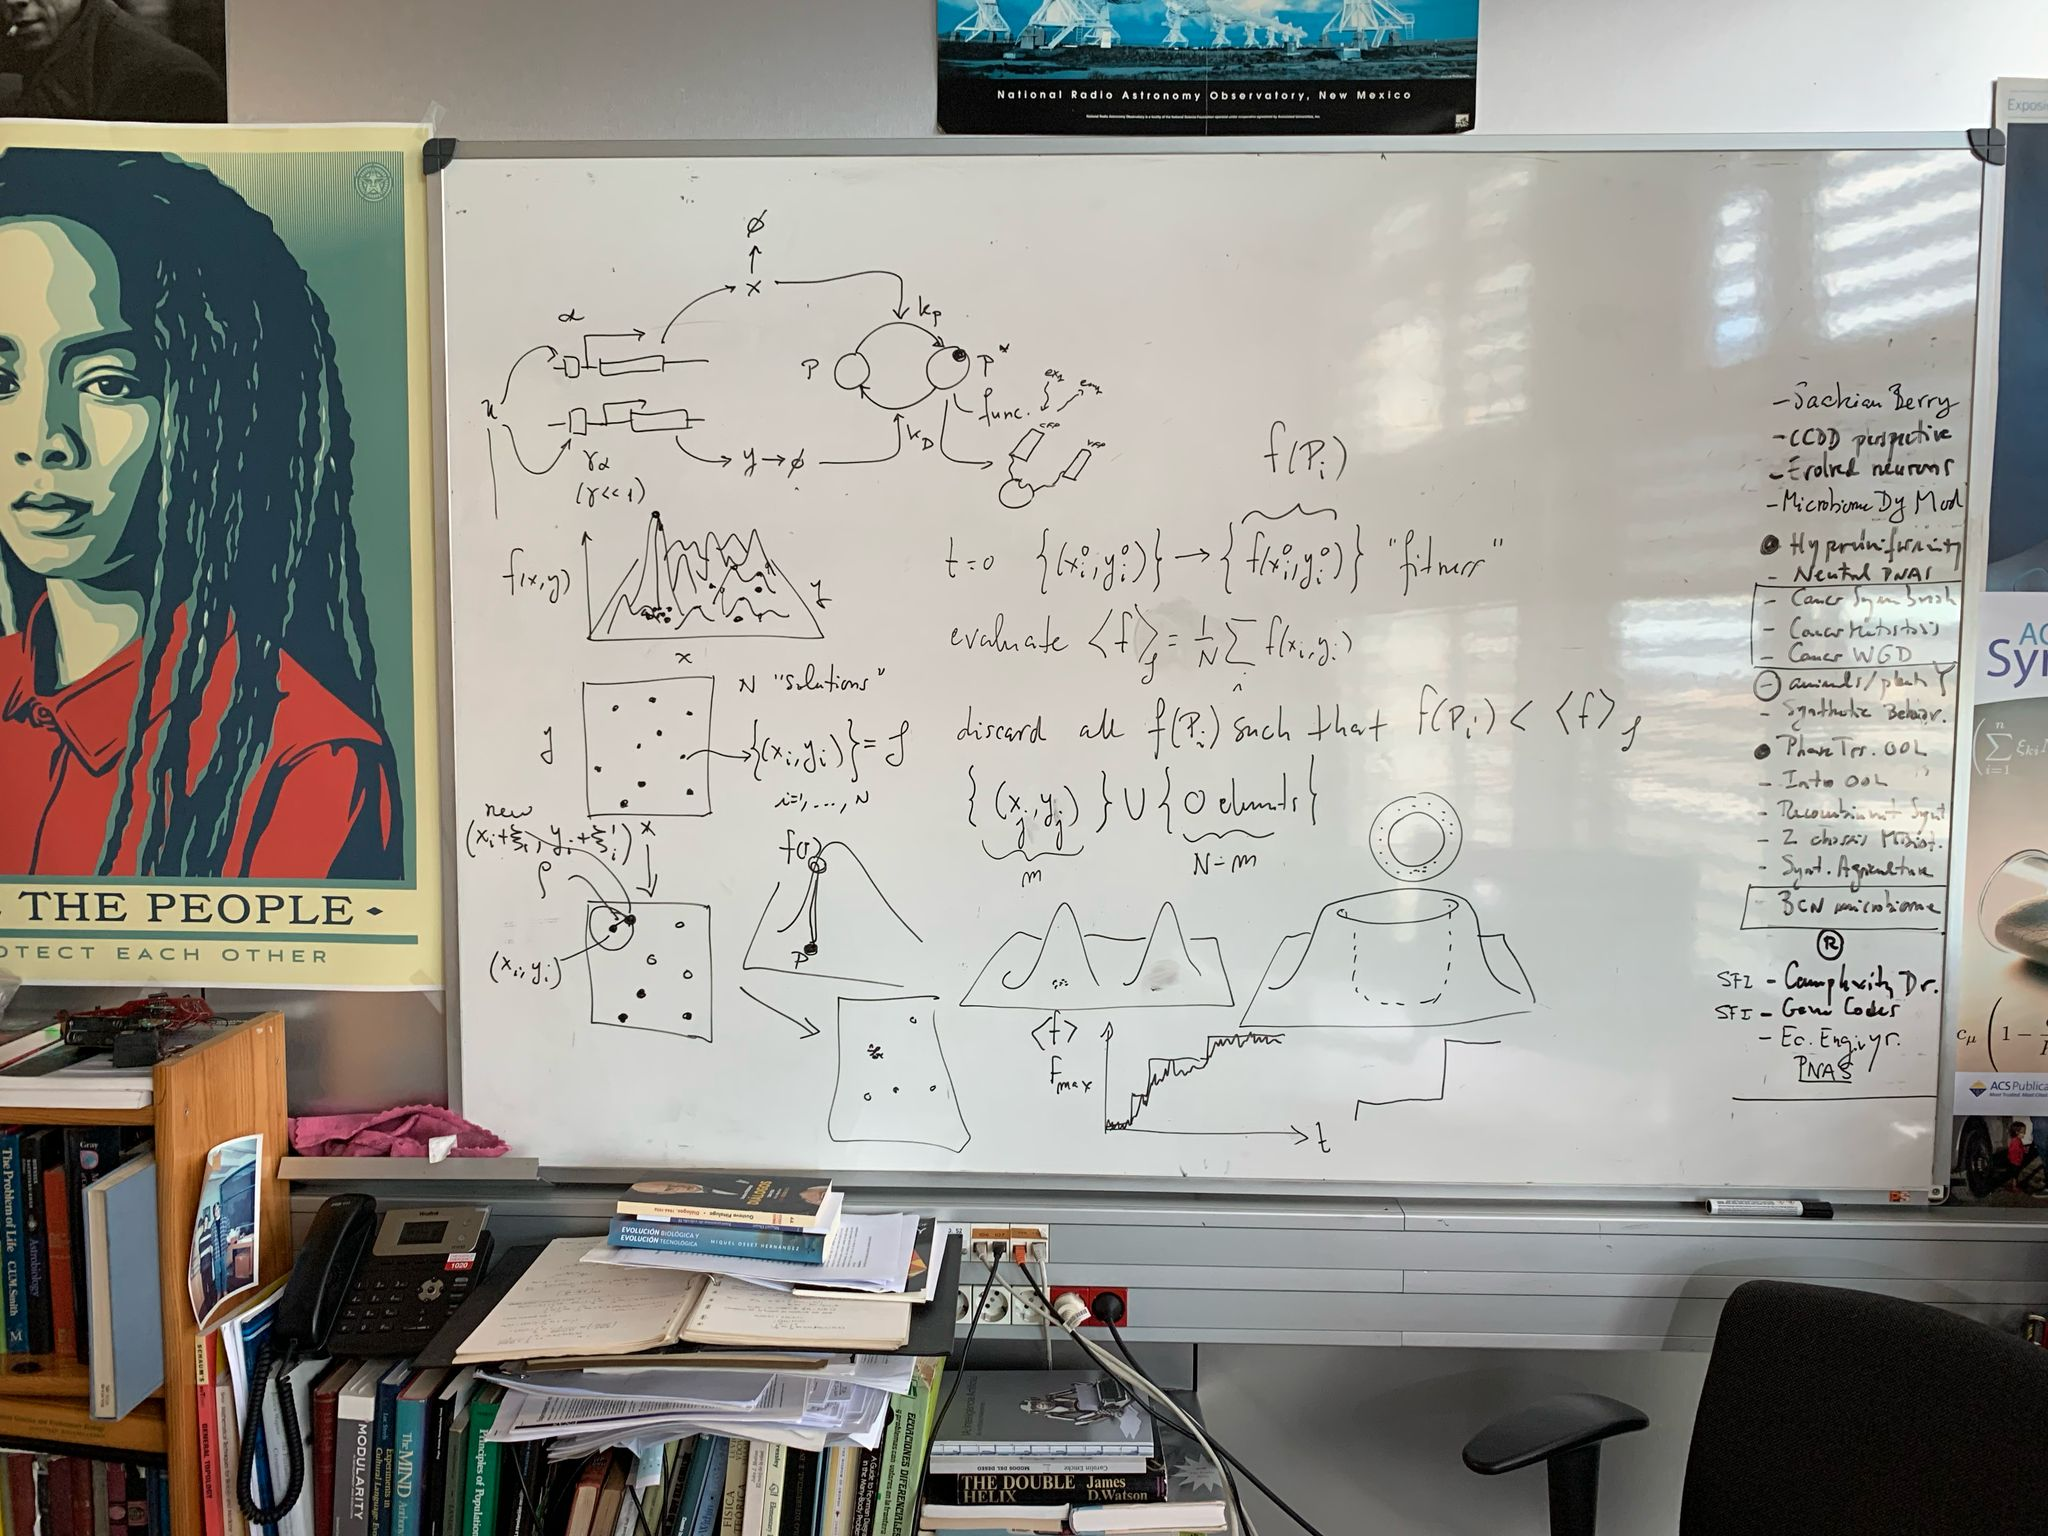

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import cm   # colormap
from matplotlib.ticker import LinearLocator     # for having ticks evenly spaced on the axis
from mpl_toolkits.mplot3d import Axes3D

import evolutionary_programming as ep

In [2]:
# fixed 1 gaussian peak 3d landscape
def f(x,y):
    return np.exp(-0.1*(x)**2 - 0.1*(y)**2)

In [3]:
par = {'N': 1000,
       'coord_range': np.array([0,10]),
       'sol_ratio': 1/5,    # eta
       'mutation_radius': 1/20, # mu
       'seed': 12345,
       'n_iter': 200,
       'eps': 0.01}  # epsilon (precision on convergence)

func_par = {'alphas': np.random.uniform(0.,2.,50),
            'offsetsx': np.random.uniform(0.,10.,50),
            'offsetsy':np.random.uniform(0.,10.,50)}

# generate a random 3d landscape by sum of gaussians whose parameters are extracted from a uniform distribution
def f(x,y,func_par:dict):
       alphas, offsetsx, offsetsy = func_par['alphas'], func_par['offsetsx'], func_par['offsetsy']
       f = np.zeros((x.shape))
       for i in range(len(alphas)):
              f += alphas[i] * np.exp(-(x-offsetsx[i])**2-(y-offsetsy[i])**2)     
       return f / np.max(f)

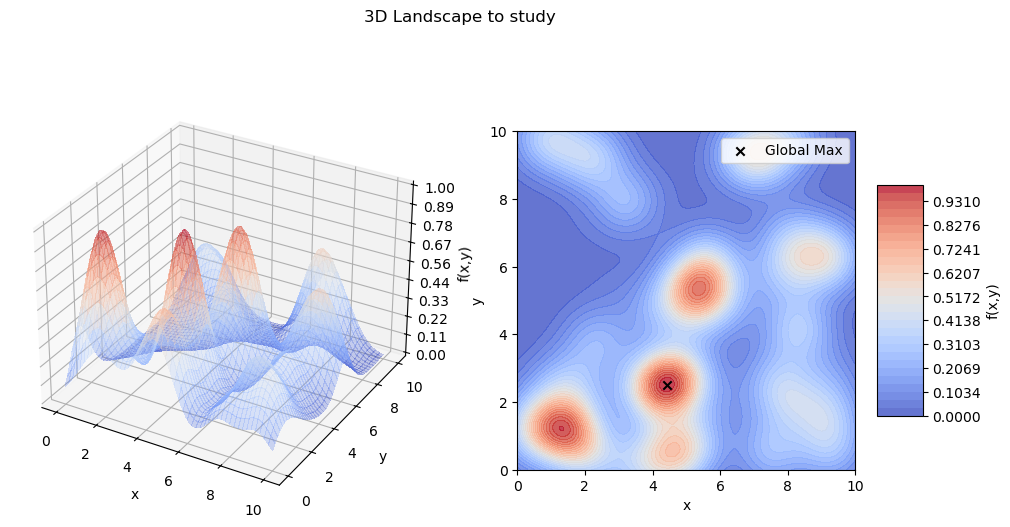

In [4]:
title = '3D Landscape to study'
coord_range = par['coord_range']
N = par['N']
x = np.linspace(coord_range[0],coord_range[1],N)
y = np.linspace(coord_range[0],coord_range[1],N)
X,Y = np.meshgrid(x,y)

fig= plt.figure(figsize=(12,6))
fig.suptitle(title)

# First subplot (3d view)
ax = fig.add_subplot(1,2,1,projection='3d')
surf = ax.plot_surface(X, Y, f(X,Y,func_par), cmap=cm.coolwarm, linewidth=0, antialiased=False,alpha=0.3)

# Customize the z axis.
ax.zaxis.set_major_locator(LinearLocator(10))
ax.set_zlim(0.0)
# A StrMethodFormatter is used automatically
ax.zaxis.set_major_formatter('{x:.02f}')

# Add axis labels
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('f(x,y)')


# Second subplot (2d view)
ax = fig.add_subplot(1,2,2)
ax.set_aspect('equal', adjustable='box')
ax.set_xlabel('x')
ax.set_ylabel('y')
levels = np.linspace(0,np.max(f(x,y,func_par)),30)
contour = ax.contourf(X,Y,f(X,Y,func_par),cmap=cm.coolwarm, antialiased=False,levels=levels,alpha=0.8)
ax.scatter(X[np.argmax(f(X,Y,func_par)) // N, np.argmax(f(X,Y,func_par)) % N], 
           Y[np.argmax(f(X,Y,func_par)) // N, np.argmax(f(X,Y,func_par)) % N], 
           marker='x', c='black', label='Global Max')
ax.legend()
# Add a color bar which maps values to colors.
fig.colorbar(contour, shrink=0.5, aspect=5,label='f(x,y)')

plt.savefig('plots/landscape.png')
plt.show()

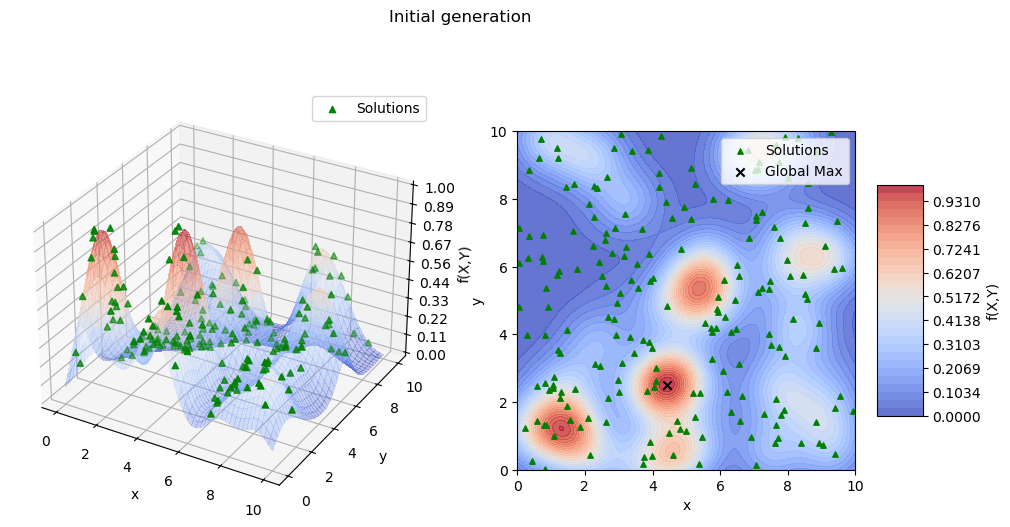

Iteration #0...


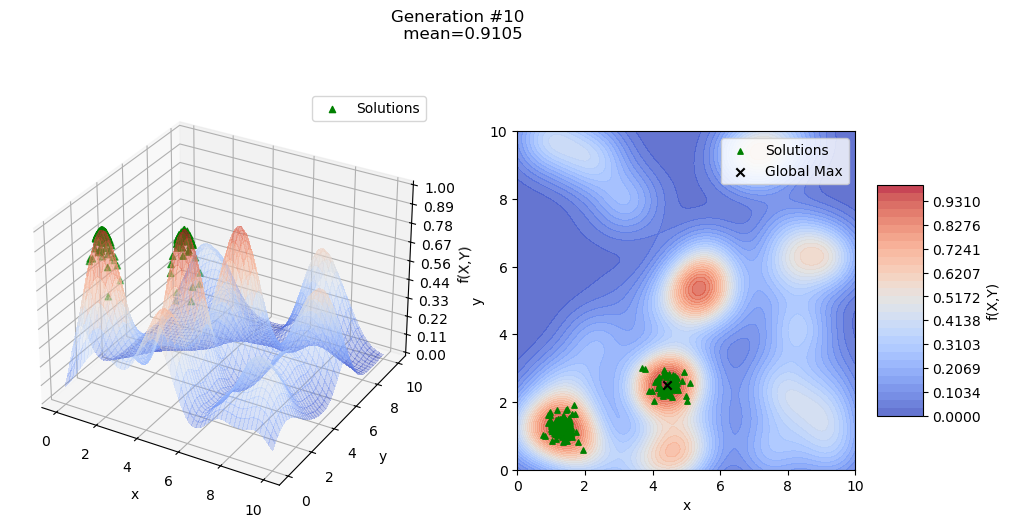

Iteration #10...
Iteration #20...
Iteration #30...
Iteration #40...
Iteration #50...
Iteration #60...
Iteration #70...
Iteration #80...
Iteration #90...
Iteration #100...
Iteration #110...
Iteration #120...
Iteration #130...
Iteration #140...
Iteration #150...
Iteration #160...
Iteration #170...
Iteration #180...
Iteration #190...
Maximum number of iterations (200) reached.


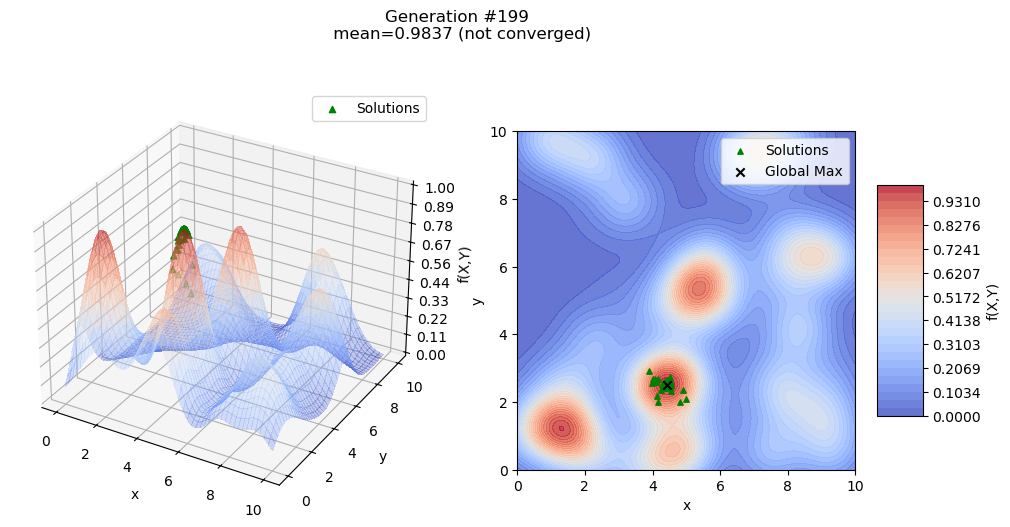

In [5]:
mean_ev, max_ev = ep.ep2d(f,par,func_par=func_par,verb=0)

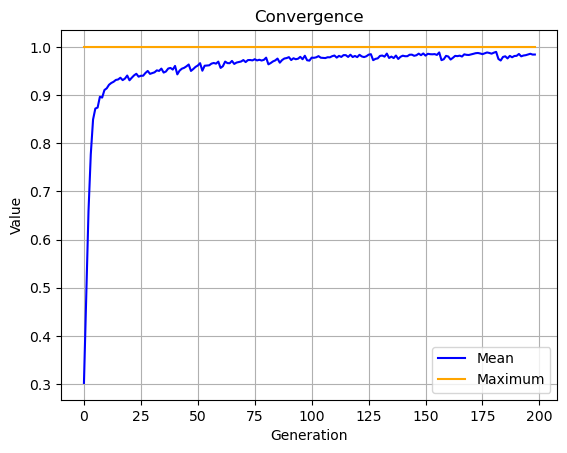

In [6]:
plt.plot(mean_ev,c='b',label='Mean')
plt.plot(max_ev,c='orange',label='Maximum')
plt.legend()
plt.grid(True)
plt.title('Convergence')
plt.ylabel('Value')
plt.xlabel('Generation')
plt.savefig('plots/convergence.png')
plt.show()

In [7]:
np.max(f(X,Y,func_par))
mean_ev

array([0.30238798, 0.48314173, 0.65914534, 0.77685794, 0.84926689,
       0.87202169, 0.87407764, 0.89648767, 0.89483369, 0.91052919,
       0.91403348, 0.92136536, 0.92514397, 0.92759893, 0.93142962,
       0.93241412, 0.9360117 , 0.93107418, 0.93426232, 0.94057169,
       0.93076044, 0.936017  , 0.94088791, 0.94421935, 0.93821669,
       0.94012487, 0.9402038 , 0.94592626, 0.95011258, 0.9440702 ,
       0.94566501, 0.94729312, 0.95133497, 0.95017967, 0.95503002,
       0.94673856, 0.94898538, 0.95513438, 0.95639461, 0.95293045,
       0.96056508, 0.94301366, 0.95080795, 0.95480794, 0.95658523,
       0.95967449, 0.9634834 , 0.95016838, 0.95408364, 0.95854539,
       0.96137692, 0.96625573, 0.95060309, 0.96093251, 0.9614445 ,
       0.96183328, 0.96531126, 0.9666745 , 0.96531588, 0.96948118,
       0.95638252, 0.95989361, 0.96956583, 0.96640325, 0.96617645,
       0.97092873, 0.96466978, 0.96751631, 0.96866535, 0.96973279,
       0.97271697, 0.96851661, 0.97265379, 0.97282351, 0.97202